In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import random
import time

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776235433.336237 1092285 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776235433.942169 1092285 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.makedirs("figures", exist_ok=True)

pileups = np.load("pileup_waveforms.npz")
X_pileup = pileups["pileup_wf"].astype(np.float32)   # (N, 104)

y_1 = pileups["primary_label"]
y_2 = pileups["secondary_label"]
Y = np.column_stack([y_1, y_2]).astype(np.float32)   # (N, 2) - float32 for BCE

# --- 60/20/20 train/val/test split ---
X_tv, X_test, Y_tv, Y_test = train_test_split(
    X_pileup, Y, test_size=0.2, random_state=42,
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_tv, Y_tv, test_size=0.25, random_state=42,
)

# --- MinMax scale to [0, 1] using only training statistics ---
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# --- Add channel dim for CNN models: (N, 104, 1) ---
X_train_n = X_train[..., None]
X_val_n   = X_val[..., None]
X_test_n  = X_test[..., None]

print(f"Train: {X_train_n.shape}   Val: {X_val_n.shape}   Test: {X_test_n.shape}")
print(f"Value range: [{X_train.min():.4f}, {X_train.max():.4f}]")


Train: (104001, 104, 1)   Val: (34668, 104, 1)   Test: (34668, 104, 1)
Value range: [0.0000, 1.0000]


In [3]:
input_length = np.shape(X_train_n)[1]
latent_dim = 16 #artbitrary previously tried 8 with worse results

inputs = tf.keras.Input(shape=(input_length, 1))

#  Encoder 
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)   # 104 → 52

x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 52 → 26

x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 26 → 13

shape_before_flatten = x.shape[1:]  # (13, 128)

#bottleneck 
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x)

#  Decoder 
x = layers.Dense(shape_before_flatten[0] * shape_before_flatten[1], activation='relu')(latent)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.UpSampling1D(2)(x)  # 13 → 26
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 26 → 52
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 52 → 104
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(2, activation='sigmoid', name="classification")(clf)

#  Model (Encoder + classifier)
model = Model(inputs, [reconstruction, classification])

I0000 00:00:1776235435.205273 1092285 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "reconstruction": "mse",
        "classification": "binary_crossentropy"
    },
    loss_weights={
        "reconstruction": 1000.0,
        "classification": 1.0
    },
    metrics={
        "classification": ["binary_accuracy"]
    }
)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)

history = model.fit(
    X_train_n,
    {"reconstruction": X_train_n,
     "classification": Y_train},
    validation_data=(
        X_val_n,
        {"reconstruction": X_val_n,
         "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
)


Epoch 1/100


I0000 00:00:1776235436.811328 1092445 service.cc:153] XLA service 0x735f1c03d310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776235436.811343 1092445 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1776235436.841589 1092445 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776235437.069482 1092445 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776235437.079510 1092445 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4930__.46
E0000 00:00:1776235437.722274 1092565 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776235437.821053 1092551 subprocess_compilation.cc:348] ptxas warnin

 64/407 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_binary_accuracy: 0.5052 - classification_loss: 0.6928 - loss: 16.0215 - reconstruction_loss: 0.0153

I0000 00:00:1776235439.723225 1092445 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


394/407 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_binary_accuracy: 0.6095 - classification_loss: 0.6414 - loss: 6.2705 - reconstruction_loss: 0.0056

I0000 00:00:1776235440.902486 1092444 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4930__.46
E0000 00:00:1776235441.203028 1093067 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776235441.665165 1093061 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - classification_binary_accuracy: 0.6125 - classification_loss: 0.6387 - loss: 6.1564 - reconstruction_loss: 0.0055

I0000 00:00:1776235443.493295 1092441 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8028__.13
I0000 00:00:1776235444.086963 1092445 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8028__.13
E0000 00:00:1776235444.355509 1093663 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - classification_binary_accuracy: 0.7031 - classification_loss: 0.5547 - loss: 2.6741 - reconstruction_loss: 0.0021 - val_classification_binary_accuracy: 0.7961 - val_classification_loss: 0.4228 - val_loss: 1.0252 - val_reconstruction_loss: 6.0226e-04
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 0.8213 - classification_loss: 0.3766 - loss: 0.9465 - reconstruction_loss: 5.6977e-04 - val_classification_binary_accuracy: 0.8334 - val_classification_loss: 0.3444 - val_loss: 0.8613 - val_reconstruction_loss: 5.1671e-04
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 0.8443 - classification_loss: 0.3169 - loss: 0.8149 - reconstruction_loss: 4.9823e-04 - val_classification_binary_accuracy: 0.8536 - val_classification_loss: 0.2919 - val_loss: 0.7745 - val_reconstruction_loss: 4.8238e-04
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_binary_accuracy: 0

I0000 00:00:1776235489.442247 1092446 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_142463__.7
E0000 00:00:1776235489.701291 1099263 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776235489.792850 1099260 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1006/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step

I0000 00:00:1776235490.534153 1092441 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146028__.7


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 2s 885us/step


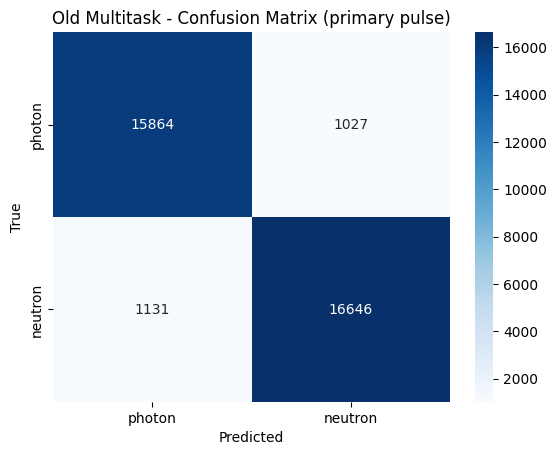

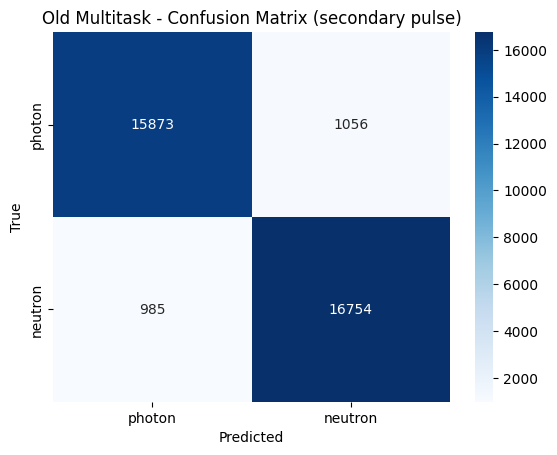

In [6]:
# Get predictions
y_pred = model.predict(X_test_n)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label (primary/secondary pulse type)
for i, name in enumerate(["primary", "secondary"]):
    cm = confusion_matrix(Y_test[:, i], y_pred_bin[:, i])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
    plt.title(f"Old Multitask - Confusion Matrix ({name} pulse)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"figures/a2_multitask_old_confusion_matrix_{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

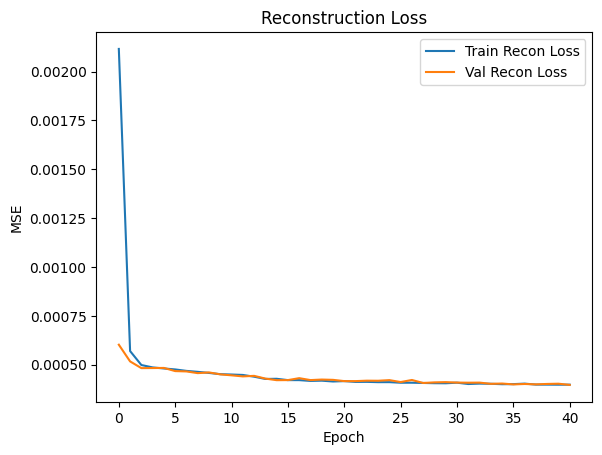

In [7]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig("figures/a2_multitask_old_reconstruction_loss.png", dpi=120, bbox_inches="tight")
plt.show()

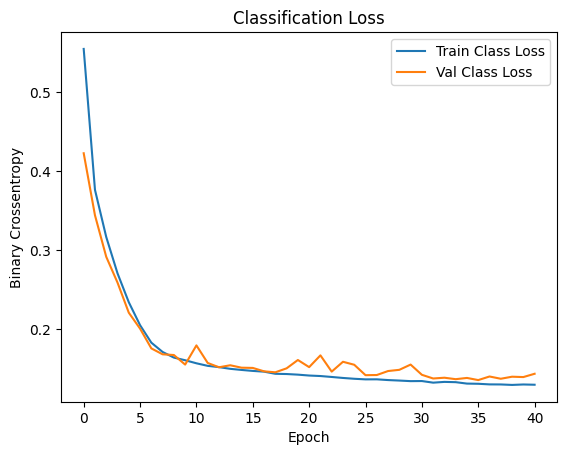

In [8]:
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.savefig("figures/a2_multitask_old_classification_loss.png", dpi=120, bbox_inches="tight")
plt.show()

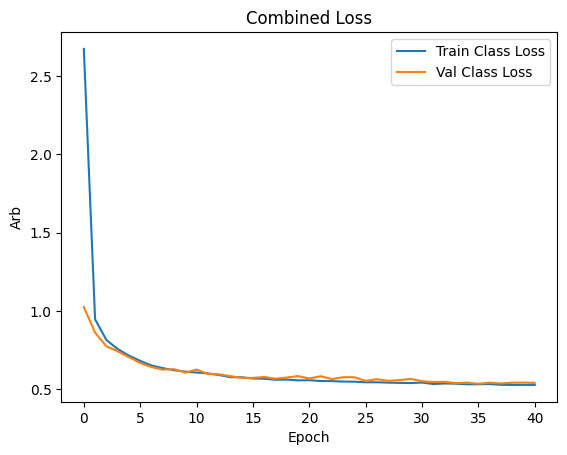

In [9]:
plt.figure()
plt.plot(history.history['loss'], label='Train Class Loss')
plt.plot(history.history['val_loss'], label='Val Class Loss')
plt.title('Combined Loss')
plt.xlabel('Epoch')
plt.ylabel('Arb')
plt.legend()
plt.savefig("figures/a2_multitask_old_classification_loss.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_classification_accuracy'], label='Val Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("figures/a2_multitask_old_classification_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

KeyError: 'classification_accuracy'

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
#Test without autoencoder

#Classifier only
inputs = tf.keras.Input(shape=(104,))
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(2, activation="sigmoid")(x)

base_model = Model(inputs, outputs)
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stop_base = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)

# Baseline uses the 2D L2-normed data (drop the channel dim)
base_model_history = base_model.fit(
    X_train_n.squeeze(-1),
    Y_train,
    validation_data=(X_val_n.squeeze(-1), Y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_base],
)


Epoch 1/100


I0000 00:00:1776217125.304133  464071 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128467__.11


360/407 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - accuracy: 0.5434 - loss: 0.6123

I0000 00:00:1776217126.278912  464070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128467__.11
I0000 00:00:1776217126.284584  464070 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1776217126.495463  470174 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 16 bytes spill stores, 16 bytes spill loads



407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5587 - loss: 0.5187 - val_accuracy: 0.5724 - val_loss: 0.4158
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.5590 - loss: 0.3824 - val_accuracy: 0.5830 - val_loss: 0.3555
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.6037 - loss: 0.3375 - val_accuracy: 0.5745 - val_loss: 0.3303
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.6237 - loss: 0.3138 - val_accuracy: 0.6067 - val_loss: 0.3068
Epoch 5/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.6302 - loss: 0.3006 - val_accuracy: 0.6273 - val_loss: 0.3013
Epoch 6/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.6350 - loss: 0.2913 - val_accuracy: 0.6332 - val_loss: 0.2858
Epoch 7/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.6395 - loss: 0.2838 - val_accuracy: 0.6462 - val_loss: 0.2820
Epoch 8/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.6429 - loss: 0.2772 - val_ac

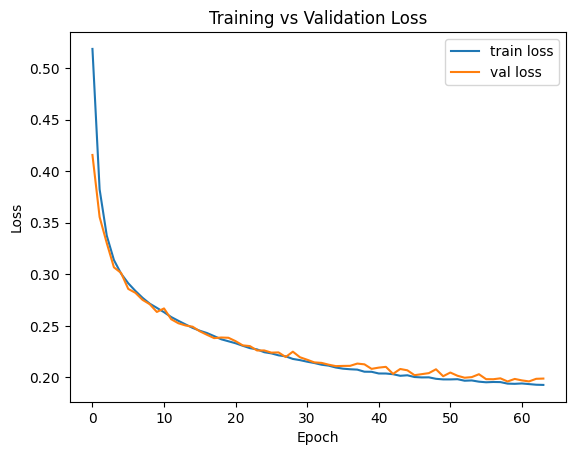

In [ ]:
import matplotlib.pyplot as plt

plt.plot(base_model_history.history['loss'], label='train loss')
plt.plot(base_model_history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("figures/a2_multitask_baseline_loss.png", dpi=120, bbox_inches="tight")
plt.show()

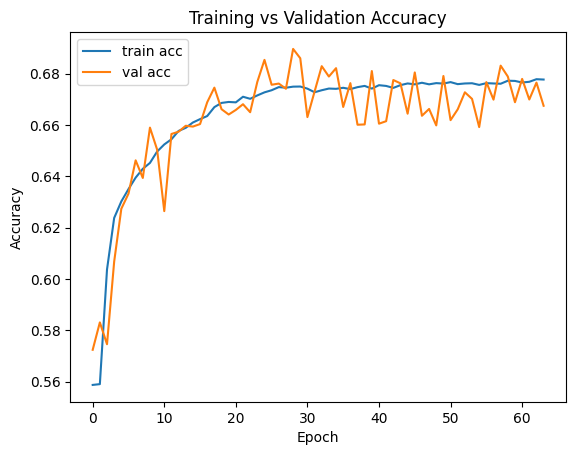

In [ ]:
plt.plot(base_model_history.history["accuracy"], label="train acc")
plt.plot(base_model_history.history["val_accuracy"], label="val acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("figures/a2_multitask_baseline_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

I0000 00:00:1776217149.836851  464070 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step


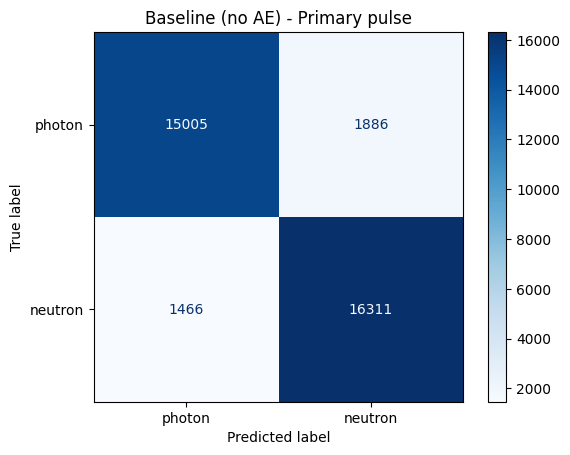

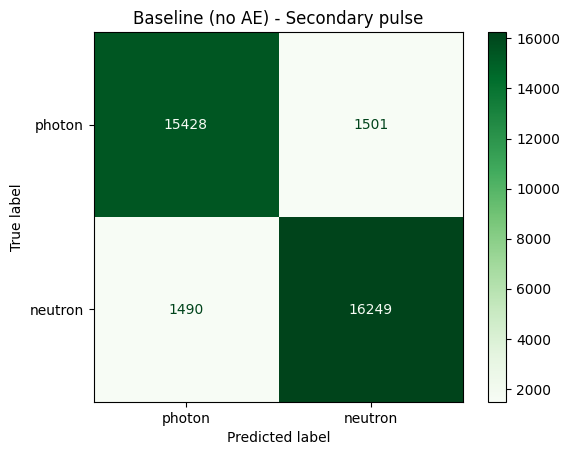

In [ ]:
import numpy as np

y_pred_probs = base_model.predict(X_test_n.squeeze(-1))
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = Y_test.astype(int)

cm0 = confusion_matrix(y_true[:, 0], y_pred[:, 0])
disp0 = ConfusionMatrixDisplay(cm0, display_labels=["photon", "neutron"])
disp0.plot(cmap="Blues", values_format="d")
plt.title("Baseline (no AE) - Primary pulse")
plt.savefig("figures/a2_multitask_baseline_confusion_matrix_primary.png", dpi=120, bbox_inches="tight")
plt.show()

cm1 = confusion_matrix(y_true[:, 1], y_pred[:, 1])
disp1 = ConfusionMatrixDisplay(cm1, display_labels=["photon", "neutron"])
disp1.plot(cmap="Greens", values_format="d")
plt.title("Baseline (no AE) - Secondary pulse")
plt.savefig("figures/a2_multitask_baseline_confusion_matrix_secondary.png", dpi=120, bbox_inches="tight")
plt.show()

## Tuned CNN Autoencoder for pileups (from a2_tune.ipynb)

This uses the best CNN configuration found by the a2 pileup hyperparameter search.
When trained jointly with the classification head (as in this notebook), accuracy
should be significantly higher than the standalone logistic-regression evaluation
in a2_tune, because the latent space gets shaped by BOTH reconstruction and
classification gradients simultaneously.

**Tuned configuration (a2_tune rank 1 CNN, composite score 0.186):**

| Hyperparameter | Value |
|---|---|
| latent_dim | 32 |
| n_conv_layers | 2 (stride-2 Conv1D) |
| kernel_size | 3 |
| n_filters_start | 64 (constant → filters = [64, 64]) |
| activation | elu |
| output_activation | linear |
| dropout | 0.3 |
| l2_reg | 1e-5 |
| noise_std | 0.02 (denoising) |
| batch_norm | False |
| optimizer | Nadam |
| learning_rate | 1e-4 |
| batch_size | 256 |
| reconstruction loss | MSE |
| n_params | ~133k |

In [ ]:
from tensorflow.keras import regularizers

input_length = np.shape(X_train_n)[1]
latent_dim_tuned = 32
l2_reg = regularizers.l2(1e-5)

tuned_inputs = tf.keras.Input(shape=(input_length, 1))

# Denoising: add slight Gaussian noise to input during training
x = layers.GaussianNoise(0.02)(tuned_inputs)

# Encoder: 2 stride-2 Conv1D layers, 64 filters each (constant), kernel 3, elu
x = layers.Conv1D(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv1D(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)

pre_flat_shape = x.shape[1:]          # (26, 64)
flat_size = int(pre_flat_shape[0] * pre_flat_shape[1])

# Latent bottleneck (32-dim)
x = layers.Flatten()(x)
tuned_latent = layers.Dense(latent_dim_tuned)(x)
tuned_latent = layers.Activation("elu", name="latent_tuned")(tuned_latent)

# Decoder: mirror encoder with Conv1DTranspose
x = layers.Dense(flat_size)(tuned_latent)
x = layers.Activation("elu")(x)
x = layers.Reshape(pre_flat_shape)(x)
x = layers.Conv1DTranspose(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)
tuned_reconstruction = layers.Conv1DTranspose(
    1, 3, strides=2, padding="same", activation="linear", name="reconstruction"
)(x)

# Classifier: Dense 32 -> 16 -> 2 (primary + secondary composition)
clf = layers.Dense(32, activation="relu")(tuned_latent)
clf = layers.Dense(16, activation="relu")(clf)
tuned_classification = layers.Dense(2, activation="sigmoid", name="classification")(clf)

tuned_model = Model(tuned_inputs, [tuned_reconstruction, tuned_classification])

tuned_model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "reconstruction": "mse",
        "classification": "binary_crossentropy",
    },
    loss_weights={"reconstruction": 10.0, "classification": 1.0}, # multiply reconstruction loss by 10
    metrics={"classification": ["accuracy"]},
)
tuned_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 104, 1)    │          0 │ input_layer_2[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 52, 64)    │        256 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 52, 64)    │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 52, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 26, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 26, 64)    │          0 │ conv1d_7[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 26, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1664)      │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │     53,280 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_tuned        │ (None, 32)        │          0 │ dense_6[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1664)      │     54,912 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1664)      │          0 │ dense_7[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 26, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 52, 64)    │     12,352 │ reshape_1[0][0]   │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 52, 64)    │          0 │ conv1d_transpose… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      1,056 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 52, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 104, 1)    │        193 │ dropout_2[0][0]   │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 134,963 (527.20 KB)

 Trainable params: 134,963 (527.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_tuned = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)

tuned_history = tuned_model.fit(
    X_train_n,
    {"reconstruction": X_train_n,
     "classification": Y_train},
    validation_data=(
        X_val_n,
        {"reconstruction": X_val_n,
         "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_tuned],
)


Epoch 1/100


I0000 00:00:1776217152.524204  464067 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_282907__.26
I0000 00:00:1776217152.591917  464067 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
E0000 00:00:1776217153.112380  478585 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


385/407 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - classification_accuracy: 0.3971 - classification_loss: 0.6619 - loss: 0.8008 - reconstruction_loss: 0.0138

I0000 00:00:1776217155.668215  464070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_282907__.26
E0000 00:00:1776217156.095244  478861 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - classification_accuracy: 0.4019 - classification_loss: 0.6585 - loss: 0.7937 - reconstruction_loss: 0.0134

I0000 00:00:1776217157.904878  464070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_285915__.14
I0000 00:00:1776217158.305916  464066 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_285915__.14


407/407 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - classification_accuracy: 0.4868 - classification_loss: 0.5963 - loss: 0.6648 - reconstruction_loss: 0.0067 - val_classification_accuracy: 0.5115 - val_classification_loss: 0.4568 - val_loss: 0.4730 - val_reconstruction_loss: 0.0015
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.5316 - classification_loss: 0.4630 - loss: 0.4890 - reconstruction_loss: 0.0025 - val_classification_accuracy: 0.5522 - val_classification_loss: 0.4120 - val_loss: 0.4253 - val_reconstruction_loss: 0.0012
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.5337 - classification_loss: 0.4346 - loss: 0.4561 - reconstruction_loss: 0.0020 - val_classification_accuracy: 0.5508 - val_classification_loss: 0.3878 - val_loss: 0.4000 - val_reconstruction_loss: 0.0011
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.5405 - classification_loss: 0.4163 - loss: 0.4350 - reconstruction_lo

I0000 00:00:1776217186.003410  464071 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_443585__.1


1015/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step

I0000 00:00:1776217186.783208  464070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_447012__.1


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step


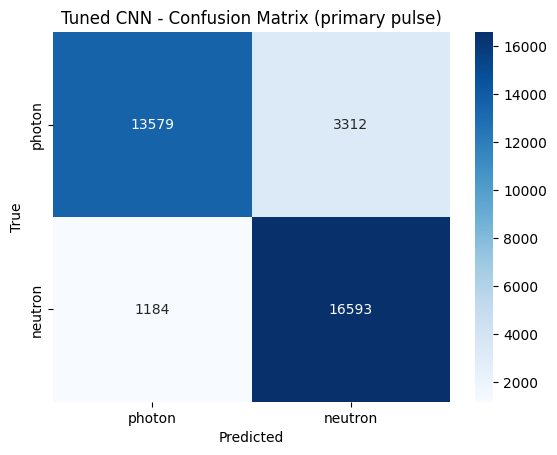

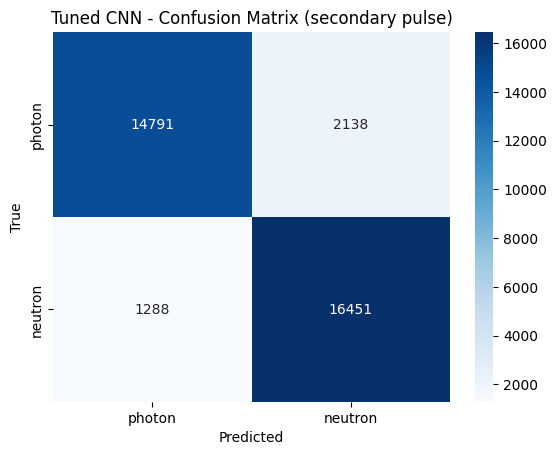

In [ ]:
y_pred_tuned = tuned_model.predict(X_test_n)[1]
y_pred_tuned_bin = (y_pred_tuned > 0.5).astype(int)

for i, name in enumerate(["primary", "secondary"]):
    cm = confusion_matrix(Y_test[:, i], y_pred_tuned_bin[:, i])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
    plt.title(f"Tuned CNN - Confusion Matrix ({name} pulse)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"figures/a2_multitask_tuned_confusion_matrix_{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

## Before / After Comparison

Side-by-side figures comparing the hand-designed pileup autoencoder with the tuned CNN autoencoder.

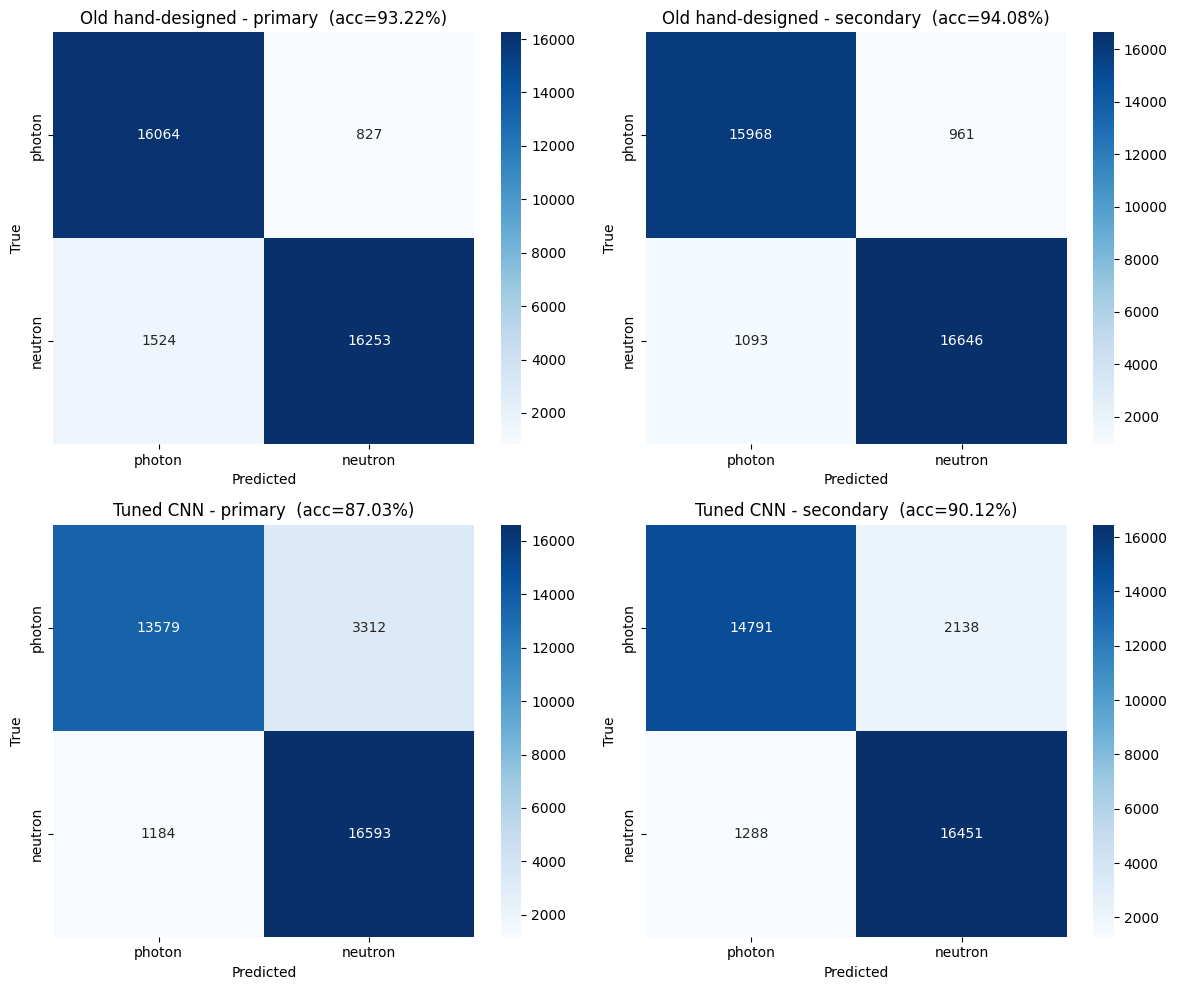

In [ ]:
# 2x2 grid: rows = old vs tuned, cols = primary vs secondary
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_info = [
    ("Old hand-designed", y_pred_bin,       "Blues"),
    ("Tuned CNN",         y_pred_tuned_bin, "Blues"),
]

for row, (model_name, preds, cmap) in enumerate(models_info):
    for col, pulse_name in enumerate(["primary", "secondary"]):
        cm = confusion_matrix(Y_test[:, col], preds[:, col])
        acc = cm.diagonal().sum() / cm.sum()
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[row, col],
                    xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
        axes[row, col].set_title(f"{model_name} - {pulse_name}  (acc={acc*100:.2f}%)")
        axes[row, col].set_xlabel("Predicted")
        axes[row, col].set_ylabel("True")

plt.tight_layout()
plt.savefig("figures/a2_multitask_compare_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

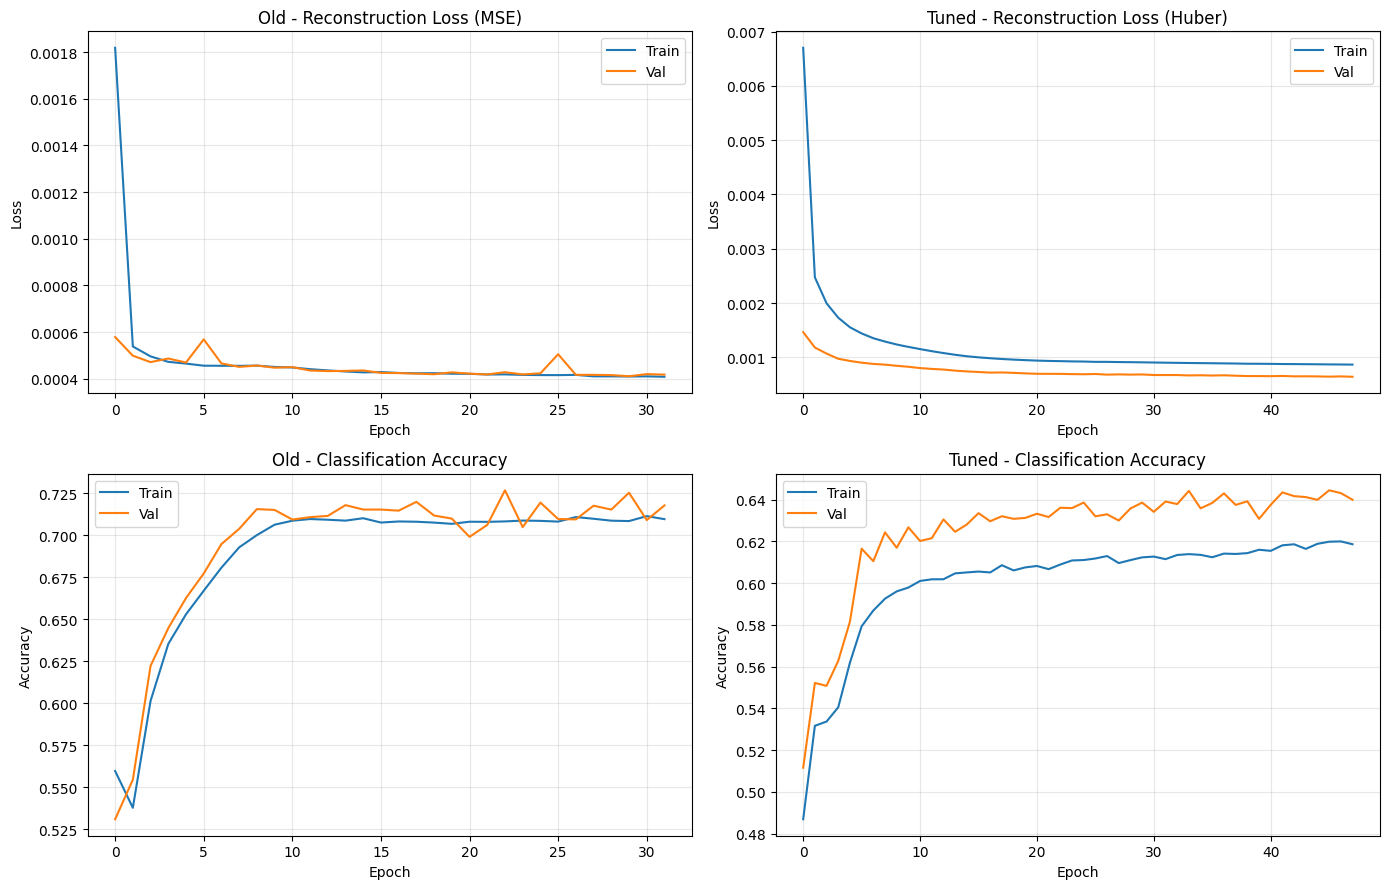

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 1: reconstruction loss
axes[0, 0].plot(history.history["reconstruction_loss"], label="Train")
axes[0, 0].plot(history.history["val_reconstruction_loss"], label="Val")
axes[0, 0].set_title("Old - Reconstruction Loss (MSE)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(tuned_history.history["reconstruction_loss"], label="Train")
axes[0, 1].plot(tuned_history.history["val_reconstruction_loss"], label="Val")
axes[0, 1].set_title("Tuned - Reconstruction Loss (Huber)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: classification accuracy
axes[1, 0].plot(history.history["classification_accuracy"], label="Train")
axes[1, 0].plot(history.history["val_classification_accuracy"], label="Val")
axes[1, 0].set_title("Old - Classification Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(tuned_history.history["classification_accuracy"], label="Train")
axes[1, 1].plot(tuned_history.history["val_classification_accuracy"], label="Val")
axes[1, 1].set_title("Tuned - Classification Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/a2_multitask_compare_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Reconstruction visualizations

Random test pileup waveforms reconstructed by each autoencoder. Black = original, blue = hand-designed, orange = tuned. Plots are in raw voltage units using the per-waveform L2 norms stored at preprocessing time.

In [ ]:
n_plot = 6
rng_plot = np.random.default_rng()
indices = rng_plot.choice(X_test_n.shape[0], size=n_plot, replace=False)

recon_old   = model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
recon_tuned = tuned_model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
orig_l2     = X_test_n[indices].squeeze(-1)

# Convert to raw voltage using stored L2 norms
sel_norms = norms_test[indices, None]
orig_show  = orig_l2     * sel_norms
old_show   = recon_old   * sel_norms
tuned_show = recon_tuned * sel_norms

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()
for ax, row, idx in zip(axes, range(n_plot), indices):
    ax.plot(orig_show[row],  label="Original",      lw=2.0, color="black")
    ax.plot(old_show[row],   label="Hand-designed", lw=1.5, linestyle="--", color="tab:blue")
    ax.plot(tuned_show[row], label="Tuned CNN",     lw=1.5, linestyle="--", color="tab:orange")
    # Label with primary/secondary composition
    p, s = Y_test[idx]
    lab = f"{'N' if p == 1 else 'G'}-{'N' if s == 1 else 'G'}"
    ax.set_title(f"test idx {idx} ({lab})", fontsize=10)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Voltage [V]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Pileup autoencoder reconstructions - random test waveforms", fontsize=13)
plt.tight_layout()
plt.savefig("figures/a2_multitask_reconstructions.png", dpi=120, bbox_inches="tight")
plt.show()

I0000 00:00:1776217188.577446  464064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_116169__.7
I0000 00:00:1776217189.073237  464070 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_447012__.1


NameError: name 'norms_test' is not defined